<a href="https://colab.research.google.com/github/BridgetteClarke/QuantumMachineLearning/blob/main/Bridgette_Clarke_Week_04_Undergrad_04_bloch_sphere.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚛️ Week 4 — The Bloch Sphere
**Track:** Undergraduate | **Lab:** Quantum Learning + TNBC Lab

---

## Overview
The Bloch sphere is the geometric representation of a single-qubit state space. Every pure qubit state maps to a unique point on the unit sphere, giving us an intuitive visual language for gates and transformations.

**Learning Objectives:**
- Parameterize qubit states using polar angles θ and φ
- Visualize single-qubit states on the Bloch sphere
- Interpret gate actions as rotations on the sphere
- Understand the North and South poles as |0⟩ and |1⟩

## 📚 Concept Review

### Bloch Sphere Parameterization
Any pure single-qubit state can be written as:
$$|\psi\rangle = \cos\left(\frac{\theta}{2}\right)|0\rangle + e^{i\phi}\sin\left(\frac{\theta}{2}\right)|1\rangle$$

| State | θ | φ | Position |
|-------|---|---|----------|
| $\|0\rangle$ | 0 | — | North pole |
| $\|1\rangle$ | π | — | South pole |
| $\|+\rangle$ | π/2 | 0 | +X axis |
| $\|-\rangle$ | π/2 | π | −X axis |
| $\|i\rangle$ | π/2 | π/2 | +Y axis |

## 🔧 Environment Setup

In [ ]:
import sys
!{sys.executable} -m pip install qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_bloch_vector
import numpy as np
import matplotlib.pyplot as plt
print('Environment ready ✓')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.8 MB/s eta 0:00:00
Environment ready ✓


## 🌐 Section 1 — Visualizing Basis States

|0⟩ state on Bloch sphere:


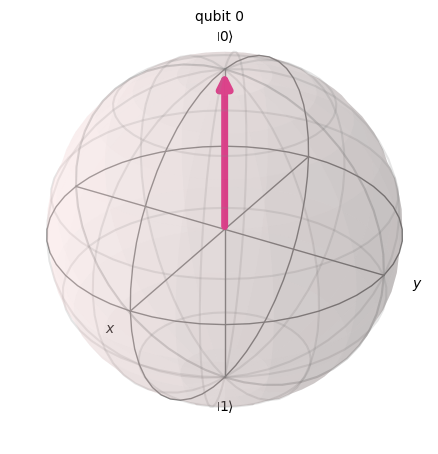

In [ ]:
# North pole: |0⟩
qc0 = QuantumCircuit(1)
sv0 = Statevector.from_instruction(qc0)
print('|0⟩ state on Bloch sphere:')
plot_bloch_multivector(sv0)

|1⟩ state on Bloch sphere:


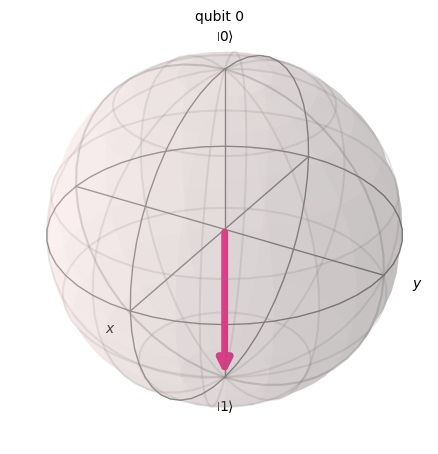

In [ ]:
# South pole: |1⟩
qc1 = QuantumCircuit(1)
qc1.x(0)
sv1 = Statevector.from_instruction(qc1)
print('|1⟩ state on Bloch sphere:')
plot_bloch_multivector(sv1)

## 🔄 Section 2 — Hadamard as 90° Rotation

|+⟩ = H|0⟩ — should point along +X axis:


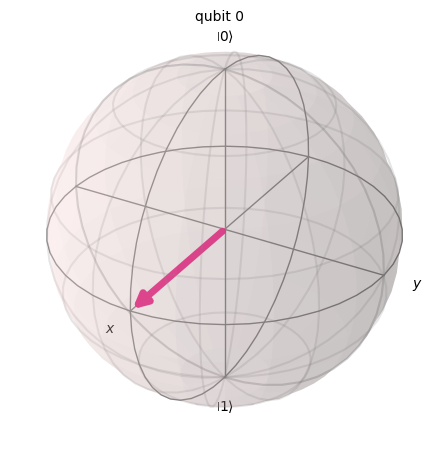

In [ ]:
# H|0⟩ = |+⟩ (moves to +X axis)
qc_h = QuantumCircuit(1)
qc_h.h(0)
sv_plus = Statevector.from_instruction(qc_h)

print('|+⟩ = H|0⟩ — should point along +X axis:')
plot_bloch_multivector(sv_plus)

## 🎡 Section 3 — Rotation Gates Rz, Rx, Ry

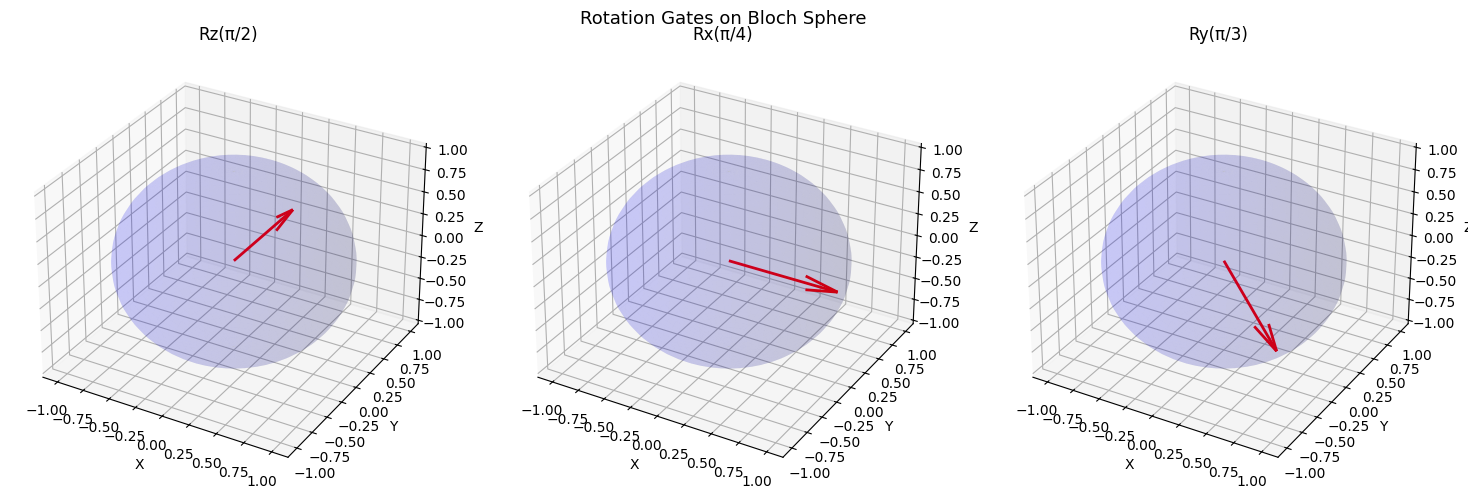

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': '3d'})

rotations = [
    ('Rz(π/2)', lambda qc: qc.rz(np.pi/2, 0)),
    ('Rx(π/4)', lambda qc: qc.rx(np.pi/4, 0)),
    ('Ry(π/3)', lambda qc: qc.ry(np.pi/3, 0)),
]

for i, (label, gate_fn) in enumerate(rotations):
    qc = QuantumCircuit(1)
    qc.h(0)       # start at |+⟩
    gate_fn(qc)   # apply rotation
    sv = Statevector.from_instruction(qc)
    # Bloch vector
    bv = sv.data
    x = 2 * (bv[0].real * bv[1].real + bv[0].imag * bv[1].imag)
    y = 2 * (bv[0].real * bv[1].imag - bv[0].imag * bv[1].real)
    z = abs(bv[0])**2 - abs(bv[1])**2
    ax = axes[i]
    ax.quiver(0,0,0, x, y, z, length=1, normalize=True, color='red', linewidth=2)
    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    ax.plot_surface(np.outer(np.cos(u), np.sin(v)),
                    np.outer(np.sin(u), np.sin(v)),
                    np.outer(np.ones(50), np.cos(v)),
                    alpha=0.1, color='blue')
    ax.set_title(label)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.suptitle('Rotation Gates on Bloch Sphere', fontsize=13)
plt.tight_layout()
plt.show()

## 🎯 Exercise 1
Visualize the $|{-}\rangle$ and $|i\rangle$ states on the Bloch sphere. What are their θ and φ values?

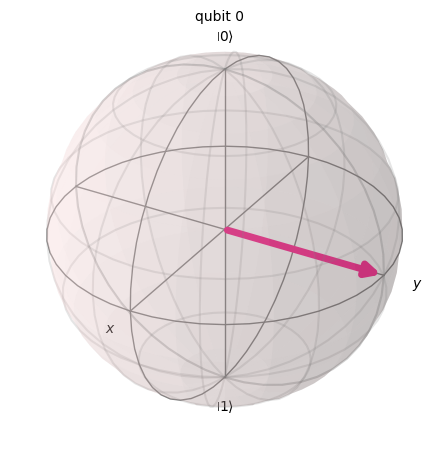

In [10]:
# ── TODO ──
# |−⟩ = H|1⟩ = (|0⟩ - |1⟩)/√2
qc_minus = QuantumCircuit(1)
# YOUR CODE HERE
qc_minus.x(0)   # flip to |1⟩
qc_minus.h(0)   # H|1⟩ = |−⟩
sv_minus = Statevector.from_instruction(qc_minus)
plot_bloch_multivector(sv_minus)


qc_i = QuantumCircuit(1)
qc_i.h(0) #flip to superposition
qc_i.s(0) #flip to |i⟩
sv_i = Statevector.from_instruction(qc_i)
plot_bloch_multivector(sv_i)

## Exercise 1 Reflection

In this exercise I visualized the |−⟩ and |i⟩ states on the Bloch Sphere.

To create |−⟩ I applied an X gate then an H gate to |0⟩. The X gate first
flipped the qubit from the North Pole to the South Pole, then H rotated it
to the equator on the −X axis. This confirmed that |−⟩ has θ = π/2 and φ = π.

To create |i⟩ I applied an H gate then an S gate to |0⟩. H moved the qubit
to the equator on the +X axis, then the S gate applied a π/2 phase shift
around the Z axis, rotating it to the +Y axis. This confirmed that |i⟩
has θ = π/2 and φ = π/2.

Both states sit on the equator meaning they are in superposition — exactly
halfway between |0⟩ and |1⟩. The difference between them is only their
phase φ, which controls which direction they point around the equator.

## 🎯 Exercise 2
Apply the full sequence $H \to T \to H$ to $|0\rangle$ and visualize the result. How does it compare to just $X$?

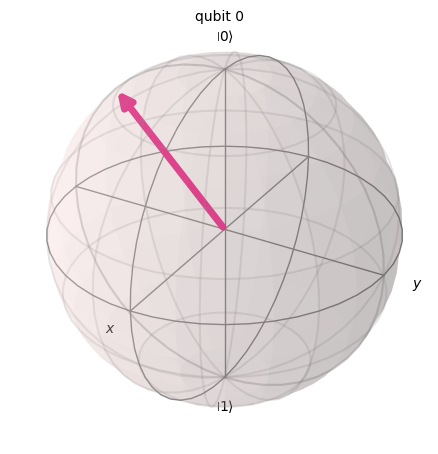

In [ ]:
# ── TODO ──
qc_htH = QuantumCircuit(1)
qc_htH.h(0)
qc_htH.t(0)
qc_htH.h(0)
sv_htH = Statevector.from_instruction(qc_htH)
plot_bloch_multivector(sv_htH)

## Exercise 2 Reflection

In this exercise I applied the sequence H → T → H to |0⟩ and compared
it to just applying X.

My prediction was that H → T → H would land at the South Pole like X,
but I was wrong. The arrow landed between the North Pole and the equator,
tilted toward the X direction.

The reason is the T gate. T applies a small π/4 phase rotation around the
Z axis. So when H was applied the second time, the qubit was coming from
a different position on the equator than it started, meaning H could not
simply undo itself.

The key lesson is that gate sequences are not reversible just by repeating
them — if anything changes the phase in between, the result is completely
different. This matters for quantum ML because small changes in rotation
angles during training produce different qubit positions, which is how the
model learns.

## 💡 Key Takeaways
- The Bloch sphere represents **all pure single-qubit states** as points on a unit sphere
- Quantum gates are **rotations** around the X, Y, or Z axis
- $|0\rangle$ = North Pole, $|1\rangle$ = South Pole, $|\pm\rangle$ on the equator
- The global phase is unobservable — only the **relative phase** φ matters

## 📝 TODO Checklist
- [ ] Complete Exercise 1: |-⟩ and |i⟩ on Bloch sphere
- [ ] Complete Exercise 2: H-T-H sequence analysis
- [ ] Plot all 6 cardinal states (+X,-X,+Y,-Y,+Z,-Z) in one figure
- [ ] Explain why the Bloch sphere only represents SINGLE qubit states

---
*Quantum Learning + TNBC Lab | Undergraduate Track | Week 4*

## 📝 Assignment 4: Plot 3 states on the Bloch sphere and explain what each axis represents.

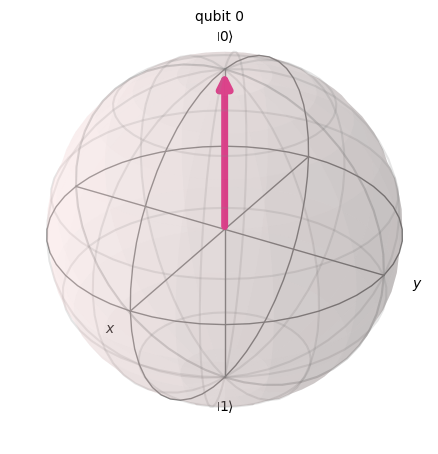

In [ ]:
# State 1: |0⟩ — Z axis (North Pole)
qc0 = QuantumCircuit(1)
sv0 = Statevector.from_instruction(qc0)
display(plot_bloch_multivector(sv0))

### State 1: |0⟩ — The Z Axis | Bridgette Clarke

The Z axis represents the classical basis states of a qubit. The North Pole
is |0⟩ and the South Pole is |1⟩. When no gates are applied the qubit starts
at the North Pole by default. The Z axis is important because it shows us
where the qubit is in terms of its classical values — how much |0⟩ versus
|1⟩ it contains. This is the foundation of the Bloch Sphere.

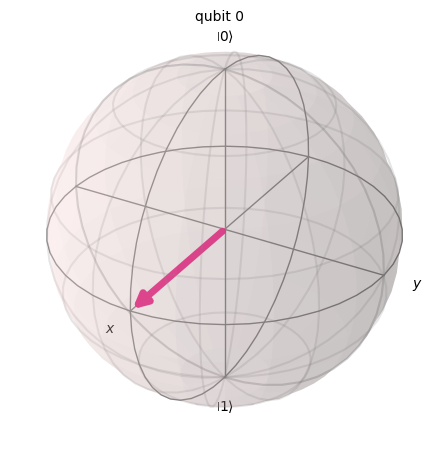

In [ ]:
# State 2: |+⟩ — X axis (Equator)
qc_plus = QuantumCircuit(1)
qc_plus.h(0)
sv_plus = Statevector.from_instruction(qc_plus)
display(plot_bloch_multivector(sv_plus))

### State 2: |+⟩ — The X Axis | Bridgette Clarke

The X axis represents superposition on the Bloch Sphere. When a qubit
starts at |0⟩ and the Hadamard gate is applied, it rotates 90 degrees
from the North Pole down to the equator landing on the +X axis. This
state is called |+⟩ and it means the qubit is exactly halfway between
|0⟩ and |1⟩ — it has an equal probability of being either one when measured.
If the qubit had started at |1⟩ instead and H was applied, it would land
on the −X axis as |−⟩. This difference comes from how the rotation works
depending on where you start.

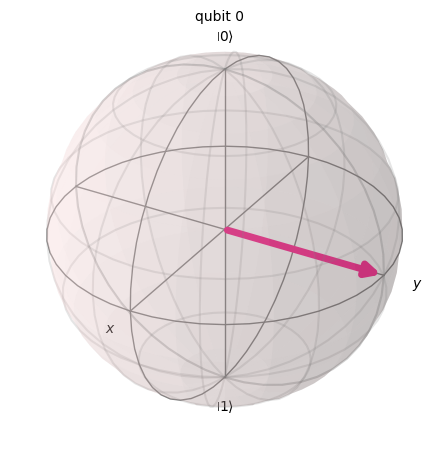

In [ ]:
# State 3: |i⟩ — Y axis (Equator)
qc_i = QuantumCircuit(1)
qc_i.h(0)
qc_i.s(0)
sv_i = Statevector.from_instruction(qc_i)
display(plot_bloch_multivector(sv_i))

### State 3: |i⟩ — The Y Axis | Bridgette Clarke

The Y axis represents states that are in superposition with a complex phase.
To create |i⟩ I applied H to put the qubit into superposition on the +X axis,
then the S gate applied a π/2 phase rotation around the Z axis which moved
the arrow to the +Y axis. The phase φ controls which direction the qubit
points around the equator. The Y axis is where φ = π/2, meaning the qubit
is in superposition but pointing in the Y direction instead of X. Phase
cannot be seen by measuring the qubit directly — it only shows up when
qubits interact with each other, which is why it matters so much in
quantum computing.